### **Without Send()**

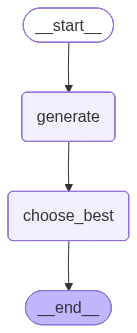

🚀 Starting poem generation...
📝 Generating poems for 3 topics...
   Writing poem about: sunset
   ✅ Completed poem for: sunset
   Writing poem about: ocean
   ✅ Completed poem for: ocean
   Writing poem about: forest
   ✅ Completed poem for: forest
🎯 Choosing the best from 3 poems...
✨ Best poem selected!
🎉 FINAL RESULT:
Topic: sunset
The sky ablaze with fiery hue,
Day's gentle kiss, a sweet adieu.
Gold and crimson softly blend,
As twilight's peaceful reign begins.


In [6]:
import operator
from typing import Annotated, TypedDict
from llm_config import llm
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Define what data flows through our graph
class AgentState(TypedDict):
    topics: list[str]                                    # Input: topics to write poems about
    poems: Annotated[list[str], operator.add]           # Output: generated poems (accumulates)

def generate_poems(state: AgentState):
    """Generate poems for all topics, one by one"""
    print(f"📝 Generating poems for {len(state['topics'])} topics...")
    
    all_poems = []
    for topic in state['topics']:
        print(f"   Writing poem about: {topic}")
        
        # Create the AI prompt
        system_prompt = SystemMessage(content="You are a talented poet")
        user_prompt = HumanMessage(content=f"Write a short 4-line poem about: {topic}")
        
        # Get poem from AI
        response = llm.invoke([system_prompt, user_prompt])
        poem = f"Topic: {topic}\n{response.content}"
        all_poems.append(poem)
        
        print(f"   ✅ Completed poem for: {topic}")
    
    return {"poems": all_poems}

def choose_best_poem(state: AgentState):
    """Pick the best poem from all generated poems"""
    print(f"🎯 Choosing the best from {len(state['poems'])} poems...")
    
    # Format all poems for evaluation
    all_poems_text = "\n\n".join([f"Poem {i+1}:\n{poem}" for i, poem in enumerate(state['poems'])])
    
    # Ask AI to pick the best one
    system_prompt = SystemMessage(content="You are a poetry critic")
    user_prompt = HumanMessage(content=f"Choose the best poem from these:\n\n{all_poems_text}")
    
    response = llm.invoke([system_prompt, user_prompt])
    
    print("✨ Best poem selected!")
    return {"poems": [f"WINNER:\n{response.content}"]}

# Build the graph - simple linear flow
builder = StateGraph(AgentState)

# Add our two steps
builder.add_node("generate", generate_poems)      # Step 1: Generate all poems
builder.add_node("choose_best", choose_best_poem) # Step 2: Pick the best one

# Connect the steps: START → generate → choose_best → END
builder.add_edge(START, "generate")
builder.add_edge("generate", "choose_best") 
builder.add_edge("choose_best", END)

# Create the runnable graph
graph = builder.compile()

# displaying Graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# Run the graph
print("🚀 Starting poem generation...")
print("="*50)

result = graph.invoke({
    "topics": ["sunset", "ocean", "forest"], 
    "poems": []
})

print("="*50)
print("🎉 FINAL RESULT:")
print("="*50)
print(result['poems'][0])

### **With Send()**

🚀 Building graph WITH Send() (Parallel Processing)


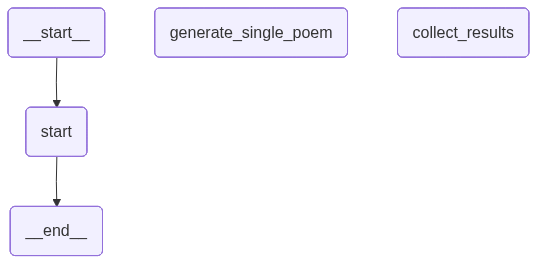


🧪 TESTING WITH Send() - Parallel Processing
🚀 Preparing to fan out 3 topics for parallel processing...
  ⚡ PARALLEL: Generating poem for 'sunset' (Thread/Process ID varies)
  ⚡ PARALLEL: Generating poem for 'ocean' (Thread/Process ID varies)
  ⚡ PARALLEL: Generating poem for 'mountain' (Thread/Process ID varies)
  ✅ PARALLEL: Completed 'mountain' in 2.10s
  ✅ PARALLEL: Completed 'sunset' in 2.13s
  ✅ PARALLEL: Completed 'ocean' in 2.20s
🎯 COLLECTING 3 poems from parallel execution...
✨ Best poem selected from parallel results!

📊 PARALLEL PROCESSING COMPLETED in 2.84 seconds
📋 Final Result: 4 poem(s)

FINAL OUTPUT:
Topic: sunset
The sky bleeds hues of fire and gold,
Day's final breath, a story told.
Across the canvas, colors creep,
As twilight lulls the world to sleep.


In [9]:
import operator
from typing import Annotated, TypedDict
from llm_config import llm
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display
import time

class ParallelAgentState(TypedDict):
    topics: list[str]
    poems: Annotated[list[str], operator.add]
    current_topic: str  # For individual poem generation

# def fan_out_topics(state: ParallelAgentState):
#     """Fan out: Create parallel tasks for each topic using Send()"""
#     print(f"🚀 Fanning out {len(state['topics'])} topics for PARALLEL processing...")
    
#     # Create a Send() for each topic - THIS IS THE KEY DIFFERENCE!
#     # Each Send() creates a separate parallel execution path
#     return [
#         Send("generate_single_poem", {"current_topic": topic, "topics": state['topics'], "poems": []}) 
#         for topic in state['topics']
#     ]
def fan_out_topics(state: ParallelAgentState):
    """Fan out: Create parallel tasks for each topic using Send()"""
    print(f"🚀 Preparing to fan out {len(state['topics'])} topics for parallel processing...")

    # Step 1: Build a list of input dictionaries—one for each topic
    topic_inputs = []
    for topic in state['topics']:
        input_data = {
            "current_topic": topic,
            "topics": state['topics'],  # Full list for context if needed
            "poems": []                 # Start with an empty list
        }
        topic_inputs.append(input_data)

    # Step 2: Send each input as a separate task using Send()
    sends = []
    for input_data in topic_inputs:
        sends.append(Send("generate_single_poem", input_data))

    return sends

def start_processing(state: ParallelAgentState):
    """Initial node that just passes the state through"""
    return state

def generate_single_poem(state: ParallelAgentState):
    """Generate poem for a single topic (runs in parallel for each topic)"""
    topic = state['current_topic']
    print(f"  ⚡ PARALLEL: Generating poem for '{topic}' (Thread/Process ID varies)")
    
    start_time = time.time()
    system_prompt = SystemMessage(content="You are one of the best poem generators")
    response = llm.invoke([
        system_prompt, 
        HumanMessage(content=f"Generate a short poem (4 lines) about: {topic}")
    ])
    end_time = time.time()
    
    print(f"  ✅ PARALLEL: Completed '{topic}' in {end_time - start_time:.2f}s")
    return {"poems": [f"Topic: {topic}\n{response.content}"]}

def collect_and_select_best(state: ParallelAgentState):
    """Fan in: Collect all parallel results and select best poem"""
    print(f"🎯 COLLECTING {len(state['poems'])} poems from parallel execution...")
    
    system_prompt = SystemMessage(content="You are one of the best poem evaluators")
    poems_text = "\n\n" + "="*50 + "\n\n".join([f"Poem {i+1}:\n{poem}" for i, poem in enumerate(state['poems'])])
    
    response = llm.invoke([
        system_prompt, 
        HumanMessage(content=f"Choose and return ONLY the best poem from these options:\n{poems_text}")
    ])
    
    print("✨ Best poem selected from parallel results!")
    return {"poems": [f"BEST POEM (from parallel execution):\n{response.content}"]}

# WITH Send() - Parallel Graph Structure
print("🚀 Building graph WITH Send() (Parallel Processing)")
builder = StateGraph(ParallelAgentState)

# Nodes for parallel execution
builder.add_node("start", start_processing)                     # Initial node
builder.add_node("generate_single_poem", generate_single_poem)  # Runs in parallel
builder.add_node("collect_results", collect_and_select_best)     # Collects parallel results

# Graph structure with parallelism
builder.add_edge(START, "start")
# Use conditional edges to return Send() objects for parallel execution
builder.add_conditional_edges("start", fan_out_topics)  # This returns Send() objects
builder.add_edge("generate_single_poem", "collect_results")  # All parallel results go to collect
builder.add_edge("collect_results", END)

graph_with_send = builder.compile()

# displaying Graph
try:
    display(Image(graph_with_send.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# Test the parallel version
print("\n" + "="*60)
print("🧪 TESTING WITH Send() - Parallel Processing") 
print("="*60)

start_time = time.time()
result = graph_with_send.invoke({
    "topics": ["sunset", "ocean", "mountain"], 
    "poems": [],
    "current_topic": ""  # Will be set by fan_out
})
total_time = time.time() - start_time

print(f"\n📊 PARALLEL PROCESSING COMPLETED in {total_time:.2f} seconds")
print(f"📋 Final Result: {len(result['poems'])} poem(s)")
print("\n" + "="*60)
print("FINAL OUTPUT:")
print("="*60)
print(result['poems'][0] if result['poems'] else "No poems generated")


<div style="background-color: #f2f2f2; padding: 10px; border-radius: 5px;">
<b style="color: #888888; font-size: 1.5em;">================================================================================</b></br>
<h2 style="color: #222222; font-size: 1.5em; display: inline;">🔍 KEY DIFFERENCES SUMMARY: </h2>
<b style="color: #888888; font-size: 1.5em;">================================================================================</b>
<p style="color: #222222;">WITHOUT <span style="background-color: #fcfcfc; padding: 2px; border-radius: 5px;">Send()</span>:</p>
<ul>
  <li style="color: #222222;">Sequential execution: <span style="background-color: #fcfcfc; padding: 2px; border-radius: 5px;">Topic 1 → Topic 2 → Topic 3</span></li>
  <li style="color: #222222;">Slower total time (sum of individual times)</li>
  <li style="color: #222222;">Simple linear graph structure</li>
  <li style="color: #222222;">One execution path through the graph</li>
</ul>
<p style="color: #222222;">WITH <span style="background-color: #fcfcfc; padding: 2px; border-radius: 5px;">Send()</span>:</p>
<ul>
  <li style="color: #222222;">Parallel execution: All topics processed simultaneously</li>
  <li style="color: #222222;">Faster total time (max of individual times, not sum)</li>
  <li style="color: #222222;">Fan-out/Fan-in pattern with <span style="background-color: #fcfcfc; padding: 2px; border-radius: 5px;">Send()</span> objects</li>
  <li style="color: #222222;">Multiple parallel execution paths that merge back together</li>
</ul>
<b style="color: #888888; font-size: 1.5em;">================================================================================</b>
</div>